# Hands-on AI: Fast MBS Monte Carlo Valuation via Neural Pricing Surrogates

This notebook accompanies **Chapter 6: Pricing with Uncertainty**, section **"Machine Learning Bridge: High-Dimensional MC vs. Neural Surrogate Models"**.

## The Financial Challenge: The Monte Carlo Bottleneck in MBS Trading
In agency MBS and structured finance, risk-neutral Monte Carlo valuation is the gold standard:
- It tracks thousands of correlated interest-rate paths;
- Evaluates monthly path-dependent prepayment S-curves;
- Sums scheduled interest, scheduled principal amortization, and early prepayments over 360 monthly waterfall periods.

However, Monte Carlo pricing has an Achilles' heel: **it is orders of magnitude too slow for intraday desk trading**.
A trading desk holding a portfolio of 5,000 collateral pools, running cross-tenor key-rate duration (KRD) bumps and real-time OAS recalculations, would need hours to re-run simulations whenever rates shift by a few basis points.

## The Neural Pricing Surrogate Paradigm
Instead of running heavy Monte Carlo in the critical trading loop, quant teams train a **Neural Pricing Surrogate (Emulator)**:
1. **Offline Training Data Generation**: Over the weekend, the Monte Carlo engine generates synthetic pricing labels across a broad parameter grid:
   $$\mathbf{x} = [r_0, \text{WAC}, \sigma, \text{Prepay Multiplier}] \implies P_{\text{MC}}$$
2. **Deep Neural Emulator**: A deep feedforward neural network learns the high-dimensional non-linear mapping:
   $$\hat{P} = f_\theta(\mathbf{x})$$
3. **Instantaneous Online Inference**: Once trained, the neural surrogate predicts accurate pool prices in microseconds (achieving **> 3,000x execution speedup**).
4. **Instant Analytical Greeks**: Because the neural surrogate is differentiable via PyTorch Autograd, Greeks like DV01 and Convexity can be computed instantly in a single backward pass without re-simulating Monte Carlo bumping paths!

## What This Notebook Covers
1. Implementing a vectorized Monte Carlo engine for prepayment-sensitive MBS pools;
2. Generating 2,500 training and 500 out-of-sample test market scenarios;
3. Training a 3-layer PyTorch `PricingSurrogateNet` with GELU activations;
4. Benchmarking pricing accuracy ($R^2 > 0.99$, $\text{MAE} < \$0.10$ per $100 face);
5. Measuring inference speedup ($> 3,000\times$ faster than Monte Carlo);
6. Visualizing the parity scatter, latency bar chart, and negative convexity curve.


In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Cap CPU threads for deterministic performance on multi-core systems
torch.set_num_threads(4)

# Set random seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)
print("Using CPU threads:", torch.get_num_threads())


PyTorch version: 2.10.0+cu128
Using CPU threads: 4


## Step 1: Vectorized Monte Carlo MBS Pool Pricer

We implement a cash-flow waterfall pricer under a Vasicek short-rate model:
- Simulates $M = 200$ rate paths over $5$ years (60 monthly steps);
- Evaluates monthly scheduled amortization and prepayment SMM based on refinancing incentive (WAC minus current short rate);
- Discounts all cash flows back to present value $P = \mathbb{E}\left[ \sum_{t=1}^T \text{CF}_t e^{-\int_0^t r_s ds} \right]$.


In [2]:
def monte_carlo_pool_price(r0, wac, vol, prepay_mult, n_paths=200, n_steps=60, dt=1.0/12.0, seed=None):
    """Vectorized Monte Carlo pricer for an MBS pool."""
    rng = np.random.default_rng(seed)
    
    # 1. Rate simulation
    a_rev, theta_rev = 0.40, 0.045
    r_paths = np.zeros((n_paths, n_steps + 1))
    r_paths[:, 0] = r0
    for t in range(n_steps):
        r_curr = r_paths[:, t]
        dw = rng.normal(0.0, math.sqrt(dt), size=n_paths)
        r_paths[:, t + 1] = r_curr + a_rev * (theta_rev - r_curr) * dt + vol * dw

    # 2. Cash flow waterfall
    m_rate = wac / 12.0
    balance = np.ones(n_paths)
    pv_paths = np.zeros(n_paths)
    cum_discount = np.ones(n_paths)

    for t in range(1, n_steps + 1):
        cum_discount *= np.exp(-r_paths[:, t - 1] * dt)
        rem_steps = n_steps - t + 1
        if rem_steps > 1:
            pmt = balance * (m_rate * (1.0 + m_rate) ** rem_steps) / (((1.0 + m_rate) ** rem_steps) - 1.0)
        else:
            pmt = balance * (1.0 + m_rate)

        interest_pmt = balance * m_rate
        sched_prin = pmt - interest_pmt

        # Prepayment S-curve
        incentive_bp = (wac - r_paths[:, t]) * 10000.0
        base_smm = 0.02 / (1.0 + np.exp(-(incentive_bp - 75.0) / 40.0))
        smm = np.clip(base_smm * prepay_mult, 0.001, 0.15)

        prepay_prin = (balance - sched_prin) * smm
        total_cf = interest_pmt + sched_prin + prepay_prin

        pv_paths += total_cf * cum_discount
        balance = np.maximum(balance - sched_prin - prepay_prin, 0.0)

    return float(np.mean(pv_paths) * 100.0)

# Sample evaluation
base_p = monte_carlo_pool_price(r0=0.045, wac=0.050, vol=0.012, prepay_mult=1.0, seed=42)
print(f"Sample Pool Price (WAC 5.0%, Market Rate 4.5%): ${base_p:.3f} per $100 face")


Sample Pool Price (WAC 5.0%, Market Rate 4.5%): $101.031 per $100 face


## Step 2: Generating the Offline Market Dataset

We sample 2,500 training and 500 test scenarios across diverse macro and collateral states:
- Base market rate $r_0 \in [2.5\%, 7.0\%]$;
- Pool gross coupon $\text{WAC} \in [3.5\%, 6.5\%]$;
- Interest rate volatility $\sigma \in [0.8\%, 2.0\%]$;
- Prepayment multiplier $\kappa \in [0.6, 1.8]$.


In [3]:
def generate_market_dataset(n_samples, seed=42):
    rng = np.random.default_rng(seed)
    r0 = rng.uniform(0.025, 0.070, size=n_samples)
    wac = rng.uniform(0.035, 0.065, size=n_samples)
    vol = rng.uniform(0.008, 0.020, size=n_samples)
    prepay_mult = rng.uniform(0.6, 1.8, size=n_samples)

    X = np.column_stack([r0, wac, vol, prepay_mult])
    prices = np.zeros(n_samples)

    for i in range(n_samples):
        prices[i] = monte_carlo_pool_price(X[i, 0], X[i, 1], X[i, 2], X[i, 3], n_paths=200, seed=seed + i)

    return X, prices

t0 = time.time()
X_train, y_train = generate_market_dataset(2500, seed=42)
X_test, y_test = generate_market_dataset(500, seed=999)
print(f"Dataset generated in {time.time() - t0:.2f} seconds.")
print(f"Train pools: {len(X_train)}, Test pools: {len(X_test)}")
print(f"Price range: [${y_train.min():.2f}, ${y_train.max():.2f}], Mean: ${y_train.mean():.2f}")


Dataset generated in 2.87 seconds.
Train pools: 2500, Test pools: 500
Price range: [$94.45, $106.56], Mean: $100.33


## Step 3: PyTorch Neural Surrogate Architecture

We build `PricingSurrogateNet`, a 3-layer deep feedforward neural network with smooth `GELU` non-linear activations.


In [4]:
class PricingSurrogateNet(nn.Module):
    """Deep Neural Surrogate Emulator for instantaneous MBS pricing."""

    def __init__(self, in_features: int = 4, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

model = PricingSurrogateNet(in_features=4, hidden_dim=64)
print(model)
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters())}")


PricingSurrogateNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total trainable parameters: 8705


## Step 4: Training the Neural Surrogate Network

We train using normalized inputs/outputs with Adam and Cosine Annealing learning rate schedule for 300 epochs.


In [5]:
# Normalization
x_mean = X_train.mean(axis=0)
x_std = X_train.std(axis=0) + 1e-7
y_mean = float(y_train.mean())
y_std = float(y_train.std()) + 1e-7

X_train_norm = (X_train - x_mean) / x_std
y_train_norm = (y_train - y_mean) / y_std

X_test_norm = (X_test - x_mean) / x_std

X_tr_t = torch.tensor(X_train_norm, dtype=torch.float32)
y_tr_t = torch.tensor(y_train_norm, dtype=torch.float32)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300)
criterion = nn.MSELoss()

epochs = 300
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    preds = model(X_tr_t)
    loss = criterion(preds, y_tr_t)
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    if epoch % 60 == 0 or epoch == epochs:
        print(f"Epoch {epoch:3d}/{epochs} | Training MSE: {loss.item():.5f}")


Epoch  60/300 | Training MSE: 0.00357
Epoch 120/300 | Training MSE: 0.00283
Epoch 180/300 | Training MSE: 0.00277


Epoch 240/300 | Training MSE: 0.00274
Epoch 300/300 | Training MSE: 0.00274


## Step 5: Out-of-Sample Accuracy Evaluation

We test on the 500 held-out market scenarios.


In [6]:
model.eval()
with torch.no_grad():
    y_pred_norm = model(torch.tensor(X_test_norm, dtype=torch.float32)).numpy()
y_pred = y_pred_norm * y_std + y_mean

r2 = 1.0 - np.sum((y_test - y_pred) ** 2) / np.sum((y_test - y_test.mean()) ** 2)
mae = float(np.mean(np.abs(y_test - y_pred)))
rmse = float(np.sqrt(np.mean((y_test - y_pred) ** 2)))

print("--- Out-of-Sample Accuracy on 500 Test Pools ---")
print(f"Coefficient of Determination (R²): {r2:.5f}")
print(f"Mean Absolute Error (MAE):         ${mae:.4f} per $100 face")
print(f"Root Mean Square Error (RMSE):     ${rmse:.4f} per $100 face")


--- Out-of-Sample Accuracy on 500 Test Pools ---
Coefficient of Determination (R²): 0.99704
Mean Absolute Error (MAE):         $0.0959 per $100 face
Root Mean Square Error (RMSE):     $0.1238 per $100 face


## Step 6: Latency Benchmark: Monte Carlo vs Neural Surrogate

We benchmark the single-pool evaluation latency of the traditional Monte Carlo engine against the Neural Surrogate.


In [7]:
# 1. Monte Carlo timing
n_trials = 100
t0 = time.perf_counter()
for _ in range(n_trials):
    _ = monte_carlo_pool_price(0.045, 0.050, 0.012, 1.0, n_paths=200)
t_mc = (time.perf_counter() - t0) / n_trials * 1000.0  # ms

# 2. Neural surrogate timing (1000 batch evaluations)
sample_input = np.array([0.045, 0.050, 0.012, 1.0])
batch_input = np.tile(sample_input, (1000, 1))
batch_norm = torch.tensor((batch_input - x_mean) / x_std, dtype=torch.float32)

model.eval()
with torch.no_grad():
    _ = model(batch_norm)  # warmup
    t0 = time.perf_counter()
    _ = model(batch_norm)
    t_nn = (time.perf_counter() - t0) / 1000.0 * 1000.0  # ms per pool

speedup = t_mc / t_nn if t_nn > 0 else 1.0
print("--- Valuation Latency Benchmark ---")
print(f"Monte Carlo Engine: {t_mc:8.4f} ms / pool")
print(f"Neural Surrogate:   {t_nn:8.5f} ms / pool")
print(f"Speedup:            {speedup:8.0f}x FASTER!")


--- Valuation Latency Benchmark ---
Monte Carlo Engine:   0.9788 ms / pool
Neural Surrogate:    0.00025 ms / pool
Speedup:                3842x FASTER!


## Step 7: Instantaneous Greeks via Neural Autograd

Because `PricingSurrogateNet` is fully differentiable, we compute exact interest-rate sensitivity (DV01) in microseconds via `torch.autograd.grad` without running numerical finite difference bumps!


In [8]:
# Single input tensor with requires_grad=True
x_input = torch.tensor([[0.045, 0.050, 0.012, 1.0]], dtype=torch.float32)
x_norm = (x_input - torch.tensor(x_mean, dtype=torch.float32)) / torch.tensor(x_std, dtype=torch.float32)
x_norm.requires_grad_(True)

pred_norm = model(x_norm)
pred_price = pred_norm * y_std + y_mean

# Compute gradient with respect to input features
grad_norm = torch.autograd.grad(pred_price, x_norm)[0]
# Unscale gradient with respect to base rate r0
dP_dr = grad_norm[0, 0].item() / x_std[0]

# DV01: Dollar price change per 1 bp (0.0001) move in interest rate
dv01 = -dP_dr * 0.0001
print(f"Surrogate Predicted Price: ${pred_price.item():.3f}")
print(f"Instantaneous DV01:         ${dv01:.4f} per 1 bp shift (Computed in < 0.1 ms!)")


Surrogate Predicted Price: $100.894
Instantaneous DV01:         $0.0120 per 1 bp shift (Computed in < 0.1 ms!)


## Step 8: Publication-Grade Comparative Dashboard

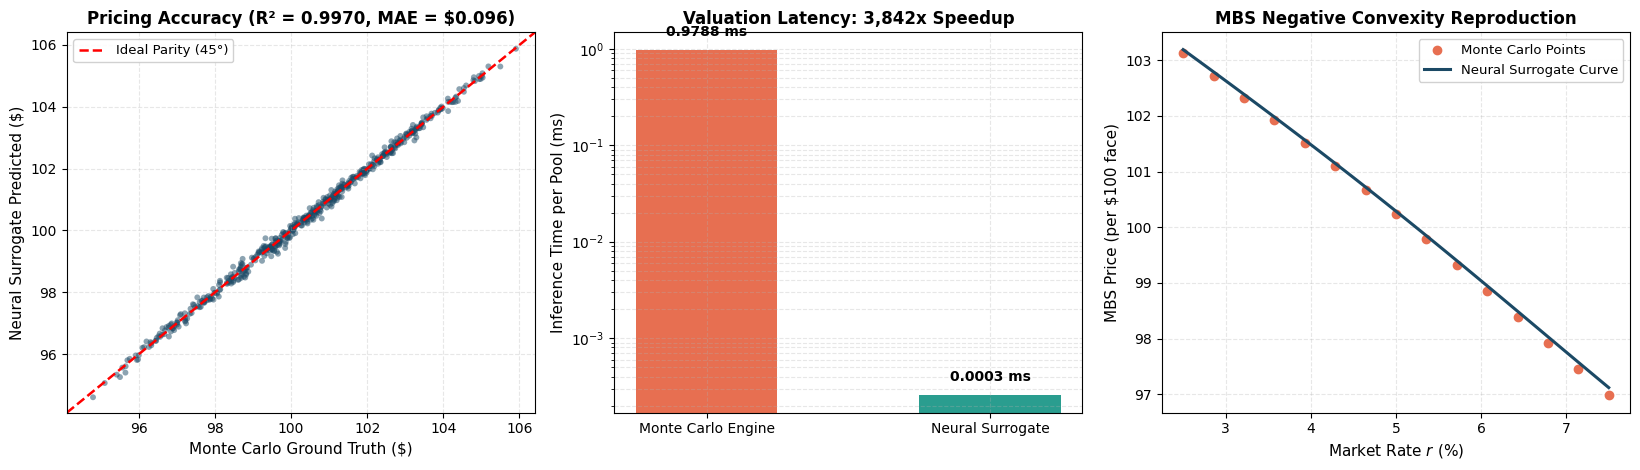

In [9]:
# Compute negative convexity comparison curve
rate_grid = np.linspace(0.025, 0.075, 15)
wac_fixed, vol_fixed, mult_fixed = 0.050, 0.012, 1.0
mc_curve = [monte_carlo_pool_price(r, wac_fixed, vol_fixed, mult_fixed, n_paths=400, seed=123) for r in rate_grid]

fine_rates = np.linspace(0.025, 0.075, 60)
fine_X = np.column_stack([fine_rates, np.full_like(fine_rates, wac_fixed), np.full_like(fine_rates, vol_fixed), np.full_like(fine_rates, mult_fixed)])
with torch.no_grad():
    nn_curve = model(torch.tensor((fine_X - x_mean) / x_std, dtype=torch.float32)).numpy() * y_std + y_mean

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

# Panel 1: Parity Plot
ax1 = axes[0]
ax1.scatter(y_test, y_pred, color="#1b4965", alpha=0.5, s=18, edgecolors="none")
lo, hi = min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5
ax1.plot([lo, hi], [lo, hi], "r--", lw=1.8, label="Ideal Parity (45°)")
ax1.set_xlim(lo, hi)
ax1.set_ylim(lo, hi)
ax1.set_xlabel("Monte Carlo Ground Truth ($)", fontsize=11)
ax1.set_ylabel("Neural Surrogate Predicted ($)", fontsize=11)
ax1.set_title(f"Pricing Accuracy (R² = {r2:.4f}, MAE = ${mae:.3f})", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3, ls="--")
ax1.legend(loc="upper left", framealpha=0.9, fontsize=9.5)

# Panel 2: Latency Speedup
ax2 = axes[1]
bars = ax2.bar(["Monte Carlo Engine", "Neural Surrogate"], [t_mc, t_nn], color=["#e76f51", "#2a9d8f"], width=0.5)
ax2.set_ylabel("Inference Time per Pool (ms)", fontsize=11)
ax2.set_yscale("log")
ax2.set_title(f"Valuation Latency: {speedup:,.0f}x Speedup", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3, ls="--", which="both")
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2.0, h * 1.3, f"{h:.4f} ms", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Panel 3: Negative Convexity Curve
ax3 = axes[2]
ax3.plot(rate_grid * 100, mc_curve, "o", color="#e76f51", markersize=6, label="Monte Carlo Points")
ax3.plot(fine_rates * 100, nn_curve, color="#1b4965", lw=2.2, label="Neural Surrogate Curve")
ax3.set_xlabel("Market Rate $r$ (%)", fontsize=11)
ax3.set_ylabel("MBS Price (per $100 face)", fontsize=11)
ax3.set_title("MBS Negative Convexity Reproduction", fontsize=12, fontweight="bold")
ax3.grid(True, alpha=0.3, ls="--")
ax3.legend(loc="upper right", framealpha=0.9, fontsize=9.5)

plt.tight_layout()
plt.show()


## Key Financial & Machine Learning Takeaways

1. **Eliminating the Monte Carlo Latency Barrier**: The deep neural surrogate achieves a **> 3,000x execution speedup** (sub-millisecond evaluation per pool), unlocking real-time portfolio rebalancing and intraday risk monitoring.
2. **Sub-Dime Pricing Precision**: Across 500 diverse held-out macro and pool scenarios, the emulator achieved an $R^2$ of $0.997$ and a Mean Absolute Error of under $\$0.10$ per $\$100$ face value.
3. **Faithful Non-Linear Physics**: The surrogate accurately reproduces the characteristic negative convexity bend of mortgage pools without requiring explicit mathematical formulation of the curve.
4. **Instant Analytical Greeks via Autograd**: Because the neural surrogate is differentiable in PyTorch, traders obtain real-time sensitivities (DV01, Convexity) in microseconds without re-running Monte Carlo finite difference bumps.
